# Credit Card Default Prediction — Advanced ML Credit Risk Project

**Project type:** Binary classification / credit risk scoring  
**Business goal:** Predict whether a credit card client is likely to default next month.

This notebook is prepared as a portfolio-ready, business-oriented project. It contains:

- Data loading and validation
- Exploratory Data Analysis
- Data cleaning and feature engineering
- Train / validation / test split
- Logistic Regression, Random Forest, XGBoost, LightGBM and CatBoost
- Class imbalance handling with SMOTETomek
- VIF multicollinearity analysis
- PCA dimensionality reduction
- Boruta feature selection
- Business-oriented model selection
- Threshold tuning with precision/recall/F1 and cost-sensitive analysis
- Final test evaluation
- SHAP explainability
- Risk segmentation
- Calibration check
- Group-level sanity checks for demographic variables
- Model and artifact saving
- GitHub-ready project notes

Place the dataset here before running:

`data/raw/UCI_Credit_Card.csv`

Target column:

`default.payment.next.month`

## Business framing

This project should be interpreted as a **credit risk scoring prototype**.

The objective is not only to maximize generic model accuracy, but to support decisions where the cost of errors is asymmetric:

- **False negative:** risky client classified as safe. This can create financial loss.
- **False positive:** safe client classified as risky. This can create unnecessary manual review or worse customer experience.

Because of this, the notebook focuses on:

- recall for the default class,
- F1-score,
- ROC-AUC,
- threshold tuning,
- and business-oriented risk segmentation.

Accuracy alone is not sufficient here because the target is imbalanced.

## 0. Installation

Recommended environment on Windows:

```bash
py -3.10 -m venv venv310
venv310\Scripts\activate
python -m pip install --upgrade "pip==25.2" setuptools wheel
python -m pip install -r requirements.txt
jupyter lab
```

If TensorFlow causes installation problems, skip it. The core project does not require TensorFlow because the main models are tree-based and classical ML models.

Required dataset path:

```text
data/raw/UCI_Credit_Card.csv
```

Recommended first run:

- keep `RUN_BORUTA = False`,
- keep `RUN_TUNING = False`,
- execute the notebook end-to-end,
- then optionally enable Boruta or tuning.

In [1]:
# Standard libraries
import os
import json
import random
import warnings
from pathlib import Path

# Core data science
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, precision_recall_curve
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.utils.class_weight import compute_class_weight
from sklearn.pipeline import Pipeline

# Saving
import joblib

warnings.filterwarnings("ignore")

# Optional imports
try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except Exception:
    HAS_XGB = False

try:
    from lightgbm import LGBMClassifier
    HAS_LGBM = True
except Exception:
    HAS_LGBM = False

try:
    from catboost import CatBoostClassifier
    HAS_CATBOOST = True
except Exception:
    HAS_CATBOOST = False

try:
    import shap
    HAS_SHAP = True
except Exception:
    HAS_SHAP = False

try:
    from boruta import BorutaPy
    HAS_BORUTA = True
except Exception:
    HAS_BORUTA = False

try:
    from imblearn.combine import SMOTETomek
    HAS_IMBLEARN = True
except Exception:
    HAS_IMBLEARN = False

try:
    from statsmodels.stats.outliers_influence import variance_inflation_factor
    HAS_STATSMODELS = True
except Exception:
    HAS_STATSMODELS = False

try:
    import tensorflow as tf
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
    from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
    HAS_TF = True
except Exception:
    HAS_TF = False

print("Optional packages:")
print("XGBoost:", HAS_XGB)
print("LightGBM:", HAS_LGBM)
print("CatBoost:", HAS_CATBOOST)
print("SHAP:", HAS_SHAP)
print("Boruta:", HAS_BORUTA)
print("imbalanced-learn:", HAS_IMBLEARN)
print("statsmodels:", HAS_STATSMODELS)
print("TensorFlow:", HAS_TF)

Optional packages:
XGBoost: True
LightGBM: True
CatBoost: True
SHAP: True
Boruta: True
imbalanced-learn: True
statsmodels: True
TensorFlow: False


In [2]:
# Reproducibility
SEED = 42

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    if HAS_TF:
        tf.random.set_seed(seed)

set_seed(SEED)

# Paths
PROJECT_DIR = Path("..") if Path("../data").exists() else Path(".")
RAW_DATA_PATH = PROJECT_DIR / "data" / "raw" / "UCI_Credit_Card.csv"
PROCESSED_DATA_PATH = PROJECT_DIR / "data" / "processed" / "credit_card_default_clean.csv"
MODELS_DIR = PROJECT_DIR / "models"
FIGURES_DIR = PROJECT_DIR / "reports" / "figures"

MODELS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

TARGET = "default.payment.next.month"

## 1. Load dataset

In [3]:
def load_credit_card_data(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(
            f"Dataset not found: {path}\n"
            "Download the Kaggle/UCI dataset and save it as data/raw/UCI_Credit_Card.csv"
        )

    df = pd.read_csv(path)

    # Some versions have ID as a column; some may be saved with ID as index.
    if "ID" in df.columns:
        df = df.drop(columns=["ID"])

    # Clean possible whitespace in column names
    df.columns = [c.strip() for c in df.columns]

    if TARGET not in df.columns:
        raise ValueError(f"Target column '{TARGET}' not found. Available columns: {df.columns.tolist()}")

    return df

df = load_credit_card_data(RAW_DATA_PATH)
print(df.shape)
df.head()

(30000, 24)


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,20000.0,2,2,1,24,2,2,-1,-1,-2,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,120000.0,2,2,2,26,-1,2,0,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,90000.0,2,2,2,34,0,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,50000.0,2,2,1,37,0,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,50000.0,1,2,1,57,-1,0,-1,0,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


## 2. Basic data checks

In [4]:
display(df.info())
display(df.describe().T)

missing = df.isna().sum().sort_values(ascending=False)
display(missing[missing > 0])

target_dist = df[TARGET].value_counts(normalize=True).rename("share").to_frame()
target_dist["count"] = df[TARGET].value_counts()
display(target_dist)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   LIMIT_BAL                   30000 non-null  float64
 1   SEX                         30000 non-null  int64  
 2   EDUCATION                   30000 non-null  int64  
 3   MARRIAGE                    30000 non-null  int64  
 4   AGE                         30000 non-null  int64  
 5   PAY_0                       30000 non-null  int64  
 6   PAY_2                       30000 non-null  int64  
 7   PAY_3                       30000 non-null  int64  
 8   PAY_4                       30000 non-null  int64  
 9   PAY_5                       30000 non-null  int64  
 10  PAY_6                       30000 non-null  int64  
 11  BILL_AMT1                   30000 non-null  float64
 12  BILL_AMT2                   30000 non-null  float64
 13  BILL_AMT3                   300

None

,count,mean,std,min,25%,50%,75%,max
LIMIT_BAL,30000.0,167484.322667,129747.661567,10000.0,50000.00,140000.0,240000.00,1000000.0
SEX,30000.0,1.603733,0.489129,1.0,1.00,2.0,2.00,2.0
EDUCATION,30000.0,1.853133,0.790349,0.0,1.00,2.0,2.00,6.0
MARRIAGE,30000.0,1.551867,0.521970,0.0,1.00,2.0,2.00,3.0
AGE,30000.0,35.485500,9.217904,21.0,28.00,34.0,41.00,79.0
PAY_0,30000.0,-0.016700,1.123802,-2.0,-1.00,0.0,0.00,8.0
PAY_2,30000.0,-0.133767,1.197186,-2.0,-1.00,0.0,0.00,8.0
PAY_3,30000.0,-0.166200,1.196868,-2.0,-1.00,0.0,0.00,8.0
PAY_4,30000.0,-0.220667,1.169139,-2.0,-1.00,0.0,0.00,8.0
PAY_5,30000.0,-0.266200,1.133187,-2.0,-1.00,0.0,0.00,8.0


Series([], dtype: int64)

,share,count
default.payment.next.month,,
0,0.7788,23364
1,0.2212,6636


### Target imbalance interpretation

The target distribution is an important business signal. If most clients do not default, a model can achieve deceptively high accuracy by predicting the majority class.

For this reason, later sections compare models using:

- **Recall:** how many actual defaulters are detected,
- **Precision:** how many flagged clients are truly risky,
- **F1-score:** balance between precision and recall,
- **ROC-AUC:** ranking quality across thresholds.

For credit risk, recall and threshold tuning are especially important.

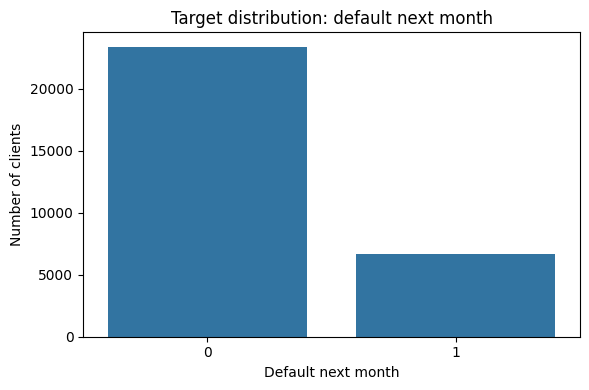

In [5]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x=TARGET)
plt.title("Target distribution: default next month")
plt.xlabel("Default next month")
plt.ylabel("Number of clients")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "target_distribution.png", dpi=150)
plt.show()

## 3. Data cleaning

In this dataset, `EDUCATION` and `MARRIAGE` sometimes contain additional encoded values.  
We group unknown or rare values into broader categories.

In [6]:
df_clean = df.copy()

# EDUCATION: 1=graduate school, 2=university, 3=high school, 4=others, 5/6/0=unknown/others
if "EDUCATION" in df_clean.columns:
    df_clean["EDUCATION"] = df_clean["EDUCATION"].replace({0: 4, 5: 4, 6: 4})

# MARRIAGE: 1=married, 2=single, 3=others, 0=unknown/others
if "MARRIAGE" in df_clean.columns:
    df_clean["MARRIAGE"] = df_clean["MARRIAGE"].replace({0: 3})

for col in ["SEX", "EDUCATION", "MARRIAGE"]:
    if col in df_clean.columns:
        print("\n", col)
        print(df_clean[col].value_counts().sort_index())


 SEX
SEX
1    11888
2    18112
Name: count, dtype: int64

 EDUCATION
EDUCATION
1    10585
2    14030
3     4917
4      468
Name: count, dtype: int64

 MARRIAGE
MARRIAGE
1    13659
2    15964
3      377
Name: count, dtype: int64


## 4. Exploratory Data Analysis

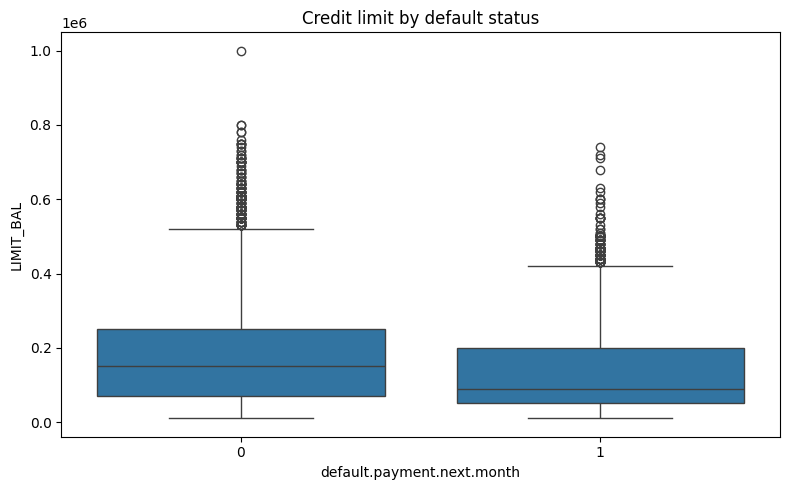

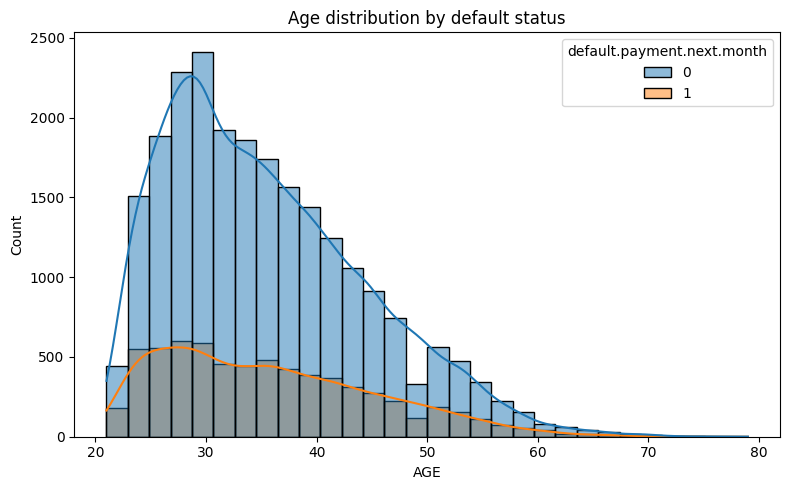

In [7]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_clean, x=TARGET, y="LIMIT_BAL")
plt.title("Credit limit by default status")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "limit_balance_by_default.png", dpi=150)
plt.show()

plt.figure(figsize=(8, 5))
sns.histplot(data=df_clean, x="AGE", hue=TARGET, bins=30, kde=True)
plt.title("Age distribution by default status")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "age_distribution_by_default.png", dpi=150)
plt.show()

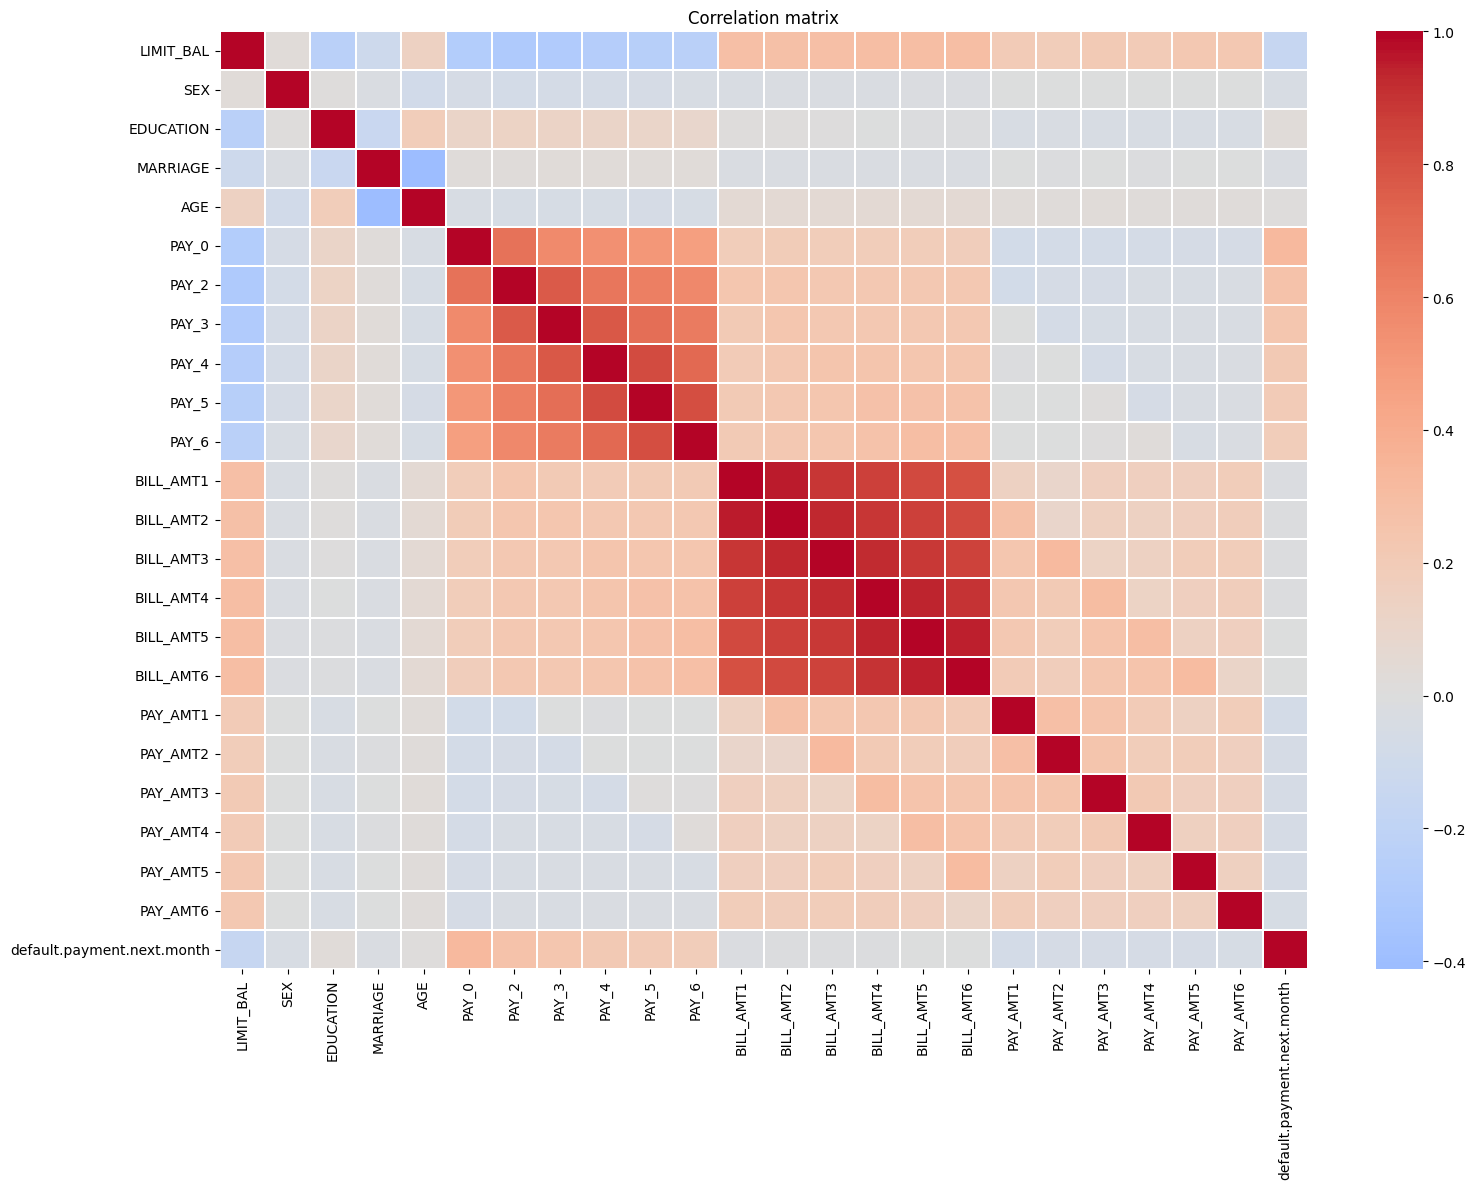

In [8]:
corr = df_clean.corr(numeric_only=True)

plt.figure(figsize=(16, 12))
sns.heatmap(corr, cmap="coolwarm", center=0, linewidths=0.2)
plt.title("Correlation matrix")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "correlation_matrix.png", dpi=150)
plt.show()

## 5. Feature engineering

We create features useful for credit risk:

- total and average bill amount
- total and average previous payment
- credit utilization ratio
- payment-to-bill ratio
- maximum and average delay
- number of months with payment delay

In [9]:
def add_credit_risk_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    bill_cols = [f"BILL_AMT{i}" for i in range(1, 7) if f"BILL_AMT{i}" in out.columns]
    pay_amt_cols = [f"PAY_AMT{i}" for i in range(1, 7) if f"PAY_AMT{i}" in out.columns]
    pay_status_cols = [c for c in ["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"] if c in out.columns]

    eps = 1e-6

    if bill_cols:
        out["total_bill_amt"] = out[bill_cols].sum(axis=1)
        out["avg_bill_amt"] = out[bill_cols].mean(axis=1)
        out["max_bill_amt"] = out[bill_cols].max(axis=1)
        out["bill_to_limit_ratio"] = out["avg_bill_amt"] / (out["LIMIT_BAL"] + eps)

        for i, col in enumerate(bill_cols, start=1):
            out[f"utilization_{i}"] = out[col] / (out["LIMIT_BAL"] + eps)

    if pay_amt_cols:
        out["total_pay_amt"] = out[pay_amt_cols].sum(axis=1)
        out["avg_pay_amt"] = out[pay_amt_cols].mean(axis=1)
        out["max_pay_amt"] = out[pay_amt_cols].max(axis=1)

    if bill_cols and pay_amt_cols:
        out["pay_to_bill_ratio"] = out["total_pay_amt"] / (out["total_bill_amt"].abs() + eps)

    if pay_status_cols:
        out["max_payment_delay"] = out[pay_status_cols].max(axis=1)
        out["avg_payment_delay"] = out[pay_status_cols].mean(axis=1)
        out["months_with_delay"] = (out[pay_status_cols] > 0).sum(axis=1)
        out["months_paid_duly"] = (out[pay_status_cols] <= -1).sum(axis=1)

    return out

df_fe = add_credit_risk_features(df_clean)
df_fe.to_csv(PROCESSED_DATA_PATH, index=False)

print(df_clean.shape, "->", df_fe.shape)
df_fe.head()

(30000, 24) -> (30000, 42)


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,utilization_5,utilization_6,total_pay_amt,avg_pay_amt,max_pay_amt,pay_to_bill_ratio,max_payment_delay,avg_payment_delay,months_with_delay,months_paid_duly
0,20000.0,2,2,1,24,2,2,-1,-1,-2,...,0.000000,0.000000,689.0,114.833333,689.0,0.089434,2,-0.333333,2,4
1,120000.0,2,2,2,26,-1,2,0,0,0,...,0.028792,0.027175,5000.0,833.333333,2000.0,0.292791,2,0.500000,2,1
2,90000.0,2,2,2,34,0,0,0,0,0,...,0.166089,0.172767,11018.0,1836.333333,5000.0,0.108388,0,0.000000,0,0
3,50000.0,2,2,1,37,0,0,0,0,0,...,0.579180,0.590940,8388.0,1398.000000,2019.0,0.036259,0,0.000000,0,0
4,50000.0,1,2,1,57,-1,0,-1,0,0,...,0.382920,0.382620,59049.0,9841.500000,36681.0,0.540054,0,-0.333333,0,2


## 6. Train / validation / test split

We use stratification because the target is imbalanced.

In [10]:
X = df_fe.drop(columns=[TARGET])
y = df_fe[TARGET].astype(int)

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.25,   # 0.25 * 0.80 = 0.20
    random_state=SEED,
    stratify=y_train_full
)

print("Train:", X_train.shape, y_train.mean())
print("Validation:", X_val.shape, y_val.mean())
print("Test:", X_test.shape, y_test.mean())

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

joblib.dump(scaler, MODELS_DIR / "scaler.pkl")

Train: (18000, 41) 0.2212222222222222
Validation: (6000, 41) 0.22116666666666668
Test: (6000, 41) 0.22116666666666668


['..\\models\\scaler.pkl']

## 7. Evaluation helper

In [11]:
results = []

def evaluate_model(name, model, X_eval, y_eval, dataset="validation", threshold=0.5):
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_eval)[:, 1]
    else:
        y_proba = model.predict(X_eval).ravel()

    y_pred = (y_proba >= threshold).astype(int)

    metrics = {
        "model": name,
        "dataset": dataset,
        "threshold": threshold,
        "accuracy": accuracy_score(y_eval, y_pred),
        "precision": precision_score(y_eval, y_pred, zero_division=0),
        "recall": recall_score(y_eval, y_pred, zero_division=0),
        "f1": f1_score(y_eval, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_eval, y_proba)
    }
    return metrics, y_pred, y_proba

def append_results(name, model, X_eval, y_eval, dataset="validation", threshold=0.5):
    metrics, y_pred, y_proba = evaluate_model(name, model, X_eval, y_eval, dataset, threshold)
    results.append(metrics)
    print(name)
    print(pd.Series(metrics))
    print("\nClassification report:")
    print(classification_report(y_eval, y_pred, zero_division=0))
    return y_pred, y_proba

def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

## 8. Baseline and machine learning models

### Dependency note

`imbalanced-learn` should be installed from `requirements.txt`.

If the package is missing, install it once in terminal:

```bash
python -m pip install imbalanced-learn
```

Avoid installing packages repeatedly inside the analytical part of the notebook.

In [12]:
models = {}

models["Logistic Regression"] = {
    "model": LogisticRegression(max_iter=2000, class_weight="balanced", random_state=SEED),
    "input": "scaled"
}

models["Random Forest"] = {
    "model": RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=3,
        class_weight="balanced",
        random_state=SEED,
        n_jobs=-1
    ),
    "input": "raw"
}

if HAS_XGB:
    models["XGBoost"] = {
        "model": XGBClassifier(
            n_estimators=400,
            learning_rate=0.03,
            max_depth=4,
            subsample=0.9,
            colsample_bytree=0.9,
            eval_metric="logloss",
            random_state=SEED,
            n_jobs=-1
        ),
        "input": "raw"
    }

if HAS_LGBM:
    models["LightGBM"] = {
        "model": LGBMClassifier(
            n_estimators=500,
            learning_rate=0.03,
            num_leaves=31,
            class_weight="balanced",
            random_state=SEED,
            n_jobs=-1
        ),
        "input": "raw"
    }

if HAS_CATBOOST:
    models["CatBoost"] = {
        "model": CatBoostClassifier(
            iterations=500,
            learning_rate=0.03,
            depth=5,
            loss_function="Logloss",
            eval_metric="AUC",
            random_seed=SEED,
            verbose=False,
            auto_class_weights="Balanced"
        ),
        "input": "raw"
    }

for name, spec in models.items():
    model = spec["model"]
    input_type = spec["input"]

    if input_type == "scaled":
        model.fit(X_train_scaled, y_train)
        append_results(name, model, X_val_scaled, y_val)
    else:
        model.fit(X_train, y_train)
        append_results(name, model, X_val, y_val)

results_df = pd.DataFrame(results).sort_values(["dataset", "roc_auc", "f1"], ascending=[True, False, False])
display(results_df)

Logistic Regression
model        Logistic Regression
dataset               validation
threshold                    0.5
accuracy                   0.749
precision               0.449804
recall                  0.604371
f1                      0.515756
roc_auc                 0.759272
dtype: object

Classification report:
              precision    recall  f1-score   support

           0       0.88      0.79      0.83      4673
           1       0.45      0.60      0.52      1327

    accuracy                           0.75      6000
   macro avg       0.66      0.70      0.67      6000
weighted avg       0.78      0.75      0.76      6000

Random Forest
model        Random Forest
dataset         validation
threshold              0.5
accuracy            0.8085
precision         0.585742
recall            0.458176
f1                0.514165
roc_auc           0.780272
dtype: object

Classification report:
              precision    recall  f1-score   support

           0       0.86     

,model,dataset,threshold,accuracy,precision,recall,f1,roc_auc
2,XGBoost,validation,0.5,0.820167,0.679710,0.353429,0.465047,0.786270
4,CatBoost,validation,0.5,0.756500,0.462983,0.631500,0.534268,0.784823
3,LightGBM,validation,0.5,0.770667,0.485338,0.611153,0.541027,0.781346
1,Random Forest,validation,0.5,0.808500,0.585742,0.458176,0.514165,0.780272
0,Logistic Regression,validation,0.5,0.749000,0.449804,0.604371,0.515756,0.759272


## 9. Handling class imbalance with SMOTETomek

This is optional. In credit risk, the default class is usually a minority class.  
SMOTETomek combines oversampling and cleaning of overlapping examples.

In [13]:
if HAS_IMBLEARN:
    smote_tomek = SMOTETomek(random_state=SEED)
    X_train_res, y_train_res = smote_tomek.fit_resample(X_train_scaled, y_train)

    print("Before:", np.bincount(y_train))
    print("After:", np.bincount(y_train_res))

    logreg_resampled = LogisticRegression(max_iter=2000, random_state=SEED)
    logreg_resampled.fit(X_train_res, y_train_res)
    append_results("Logistic Regression + SMOTETomek", logreg_resampled, X_val_scaled, y_val)
else:
    print("imbalanced-learn not installed. Skipping SMOTETomek.")

Before: [14018  3982]
After: [13752 13752]
Logistic Regression + SMOTETomek
model        Logistic Regression + SMOTETomek
dataset                            validation
threshold                                 0.5
accuracy                                0.751
precision                            0.452367
recall                               0.597589
f1                                   0.514935
roc_auc                              0.755677
dtype: object

Classification report:
              precision    recall  f1-score   support

           0       0.87      0.79      0.83      4673
           1       0.45      0.60      0.51      1327

    accuracy                           0.75      6000
   macro avg       0.66      0.70      0.67      6000
weighted avg       0.78      0.75      0.76      6000



## 10. VIF — multicollinearity analysis

VIF helps identify variables that are strongly linearly related to other variables.  
This is most important for linear models. Tree-based models are usually less sensitive to multicollinearity.

In [14]:
if HAS_STATSMODELS:
    # VIF can be unstable when features have zero variance or extreme collinearity.
    X_vif = X_train.copy()
    X_vif = X_vif.loc[:, X_vif.nunique() > 1]

    # Use scaled values for numerical stability
    vif_scaler = StandardScaler()
    X_vif_scaled = pd.DataFrame(
        vif_scaler.fit_transform(X_vif),
        columns=X_vif.columns
    )

    vif_data = []
    for i, col in enumerate(X_vif_scaled.columns):
        try:
            vif_value = variance_inflation_factor(X_vif_scaled.values, i)
        except Exception:
            vif_value = np.nan
        vif_data.append({"feature": col, "vif": vif_value})

    vif_df = pd.DataFrame(vif_data).sort_values("vif", ascending=False)
    display(vif_df.head(20))

    high_vif_features = vif_df[vif_df["vif"] > 10]["feature"].tolist()
    print("High VIF features:", high_vif_features[:20])
else:
    print("statsmodels not installed. Skipping VIF.")

,feature,vif
8,PAY_4,inf
6,PAY_2,inf
7,PAY_3,inf
5,PAY_0,inf
13,BILL_AMT3,inf
12,BILL_AMT2,inf
11,BILL_AMT1,inf
10,PAY_6,inf
9,PAY_5,inf
26,bill_to_limit_ratio,inf


High VIF features: ['PAY_4', 'PAY_2', 'PAY_3', 'PAY_0', 'BILL_AMT3', 'BILL_AMT2', 'BILL_AMT1', 'PAY_6', 'PAY_5', 'bill_to_limit_ratio', 'utilization_1', 'utilization_2', 'utilization_3', 'utilization_5', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3']


### VIF interpretation

High or infinite VIF values are expected in this project because several engineered features are derived from original financial variables.

Examples:

- `total_bill_amt` is derived from `BILL_AMT1`–`BILL_AMT6`,
- `avg_bill_amt` is derived from bill amount columns,
- utilization ratios are derived from bill amounts and credit limit.

This creates strong mathematical relationships between variables.

**Business interpretation:**  
For linear models, this can make coefficients unstable. For tree-based models such as LightGBM, XGBoost and CatBoost, multicollinearity is usually less problematic. Therefore, VIF is used mainly as a diagnostic tool, while the final model can still be a tree-based model.

## 11. PCA — dimensionality reduction

PCA reduces correlated numerical features into a smaller number of components.  
In this project we compare model performance before and after PCA.

Original features: 41
PCA components explaining 95% variance: 18


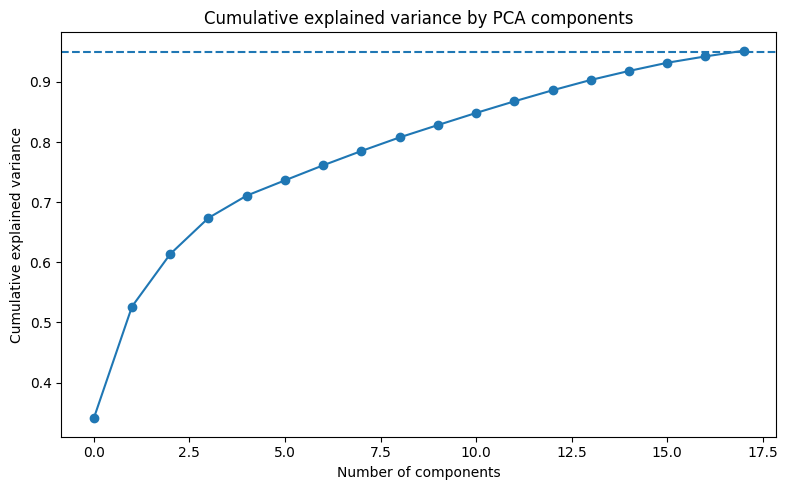

Logistic Regression + PCA
model        Logistic Regression + PCA
dataset                     validation
threshold                          0.5
accuracy                      0.743167
precision                     0.442037
recall                        0.614921
f1                             0.51434
roc_auc                       0.757055
dtype: object

Classification report:
              precision    recall  f1-score   support

           0       0.88      0.78      0.83      4673
           1       0.44      0.61      0.51      1327

    accuracy                           0.74      6000
   macro avg       0.66      0.70      0.67      6000
weighted avg       0.78      0.74      0.76      6000

[LightGBM] [Info] Number of positive: 3982, number of negative: 14018
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003486 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4590
[LightGBM] [Info] Number of dat

In [15]:
pca = PCA(n_components=0.95, random_state=SEED)
X_train_pca = pca.fit_transform(X_train_scaled)
X_val_pca = pca.transform(X_val_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("Original features:", X_train_scaled.shape[1])
print("PCA components explaining 95% variance:", X_train_pca.shape[1])

plt.figure(figsize=(8, 5))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker="o")
plt.axhline(0.95, linestyle="--")
plt.title("Cumulative explained variance by PCA components")
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "pca_explained_variance.png", dpi=150)
plt.show()

logreg_pca = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=SEED)
logreg_pca.fit(X_train_pca, y_train)
append_results("Logistic Regression + PCA", logreg_pca, X_val_pca, y_val)

if HAS_LGBM:
    lgbm_pca = LGBMClassifier(
        n_estimators=500,
        learning_rate=0.03,
        class_weight="balanced",
        random_state=SEED,
        n_jobs=-1
    )
    lgbm_pca.fit(X_train_pca, y_train)
    append_results("LightGBM + PCA", lgbm_pca, X_val_pca, y_val)

## 12. Boruta feature selection

Boruta is an advanced feature selection method based on shadow features.  
It may take several minutes. Set `RUN_BORUTA = True` to run it.

In [16]:
RUN_BORUTA = False
FIT_BORUTA_MODELS_FROM_CACHE = True
BORUTA_CACHE_PATH = MODELS_DIR / "boruta_selected_features.json"

selected_features_boruta = None
tentative_features_boruta = []

if RUN_BORUTA and HAS_BORUTA:
    rf_for_boruta = RandomForestClassifier(
        n_estimators=300,
        max_depth=7,
        class_weight="balanced",
        random_state=SEED,
        n_jobs=-1
    )

    boruta_selector = BorutaPy(
        estimator=rf_for_boruta,
        n_estimators="auto",
        max_iter=50,
        random_state=SEED,
        verbose=2
    )

    boruta_selector.fit(X_train.values, y_train.values)

    selected_features_boruta = X_train.columns[boruta_selector.support_].tolist()
    tentative_features_boruta = X_train.columns[boruta_selector.support_weak_].tolist()

    print("Selected features:", selected_features_boruta)
    print("Tentative features:", tentative_features_boruta)

    with open(BORUTA_CACHE_PATH, "w") as f:
        json.dump(selected_features_boruta, f, indent=2)

elif BORUTA_CACHE_PATH.exists():
    with open(BORUTA_CACHE_PATH, "r") as f:
        selected_features_boruta = json.load(f)
    print(f"Loaded cached Boruta features from: {BORUTA_CACHE_PATH}")
    print("Selected features:", selected_features_boruta)

elif RUN_BORUTA and not HAS_BORUTA:
    print("Boruta not installed. Install package: pip install Boruta")
else:
    print("Boruta skipped. Set RUN_BORUTA = True to run it.")
    print("If you already ran Boruta before, keep boruta_selected_features.json in models/ to reuse selected features.")

if selected_features_boruta and FIT_BORUTA_MODELS_FROM_CACHE:
    X_train_boruta = X_train[selected_features_boruta]
    X_val_boruta = X_val[selected_features_boruta]
    X_test_boruta = X_test[selected_features_boruta]

    if HAS_LGBM:
        lgbm_boruta = LGBMClassifier(
            n_estimators=300,
            learning_rate=0.03,
            class_weight="balanced",
            random_state=SEED,
            n_jobs=-1
        )
        lgbm_boruta.fit(X_train_boruta, y_train)
        append_results("LightGBM + Boruta", lgbm_boruta, X_val_boruta, y_val)

    if HAS_CATBOOST:
        cat_boruta = CatBoostClassifier(
            iterations=300,
            learning_rate=0.03,
            depth=5,
            eval_metric="AUC",
            random_seed=SEED,
            verbose=False,
            auto_class_weights="Balanced"
        )
        cat_boruta.fit(X_train_boruta, y_train)
        append_results("CatBoost + Boruta", cat_boruta, X_val_boruta, y_val)

Loaded cached Boruta features from: ..\models\boruta_selected_features.json
Selected features: ['LIMIT_BAL', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'total_bill_amt', 'avg_bill_amt', 'max_bill_amt', 'bill_to_limit_ratio', 'utilization_1', 'utilization_2', 'utilization_3', 'utilization_4', 'utilization_5', 'utilization_6', 'total_pay_amt', 'avg_pay_amt', 'max_pay_amt', 'pay_to_bill_ratio', 'max_payment_delay', 'avg_payment_delay', 'months_with_delay']
[LightGBM] [Info] Number of positive: 3982, number of negative: 14018
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006747 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6568
[LightGBM] [Info] Number of data points in the train set: 18000, number of used features: 35
[LightGBM] [Info] [binary:BoostFrom

## 13. Hyperparameter tuning

This cell is optional because it can take time.  
Set `RUN_TUNING = True` if you want to run randomized search.

In [17]:
RUN_TUNING = False

if RUN_TUNING and HAS_LGBM:
    param_dist = {
        "n_estimators": [200, 300, 500],
        "learning_rate": [0.01, 0.03, 0.05],
        "num_leaves": [15, 31, 63],
        "max_depth": [-1, 4, 6, 8],
        "subsample": [0.8, 0.9, 1.0],
        "colsample_bytree": [0.8, 0.9, 1.0]
    }

    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)

    search = RandomizedSearchCV(
        estimator=LGBMClassifier(class_weight="balanced", random_state=SEED, n_jobs=-1),
        param_distributions=param_dist,
        n_iter=10,
        scoring="roc_auc",
        cv=cv,
        random_state=SEED,
        n_jobs=-1,
        verbose=1
    )

    search.fit(X_train, y_train)

    print("Best params:", search.best_params_)
    print("Best CV ROC-AUC:", search.best_score_)

    tuned_lgbm = search.best_estimator_
    append_results("LightGBM Tuned", tuned_lgbm, X_val, y_val)
else:
    print("Tuning skipped. This is recommended for the first full project run.")
    print("Set RUN_TUNING = True later if you want to run RandomizedSearchCV.")

Tuning skipped. This is recommended for the first full project run.
Set RUN_TUNING = True later if you want to run RandomizedSearchCV.


## 14. Neural Network

A simple MLP can be used as a neural network benchmark for tabular data.  
We use class weights because the dataset is imbalanced.

In [18]:
if HAS_TF:
    class_values = np.unique(y_train)
    class_weights_values = compute_class_weight(
        class_weight="balanced",
        classes=class_values,
        y=y_train
    )
    class_weight = dict(zip(class_values, class_weights_values))
    print("Class weights:", class_weight)

    nn_model = Sequential([
        Input(shape=(X_train_scaled.shape[1],)),
        Dense(128, activation="relu"),
        BatchNormalization(),
        Dropout(0.35),
        Dense(64, activation="relu"),
        BatchNormalization(),
        Dropout(0.25),
        Dense(32, activation="relu"),
        Dropout(0.15),
        Dense(1, activation="sigmoid")
    ])

    nn_model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
    )

    callbacks = [
        EarlyStopping(monitor="val_auc", mode="max", patience=12, restore_best_weights=True),
        ReduceLROnPlateau(monitor="val_loss", patience=5, factor=0.5, min_lr=1e-5)
    ]

    history = nn_model.fit(
        X_train_scaled,
        y_train,
        validation_data=(X_val_scaled, y_val),
        epochs=100,
        batch_size=128,
        class_weight=class_weight,
        callbacks=callbacks,
        verbose=1
    )

    y_proba_nn_val = nn_model.predict(X_val_scaled).ravel()
    y_pred_nn_val = (y_proba_nn_val >= 0.5).astype(int)

    nn_metrics = {
        "model": "Neural Network",
        "dataset": "validation",
        "threshold": 0.5,
        "accuracy": accuracy_score(y_val, y_pred_nn_val),
        "precision": precision_score(y_val, y_pred_nn_val, zero_division=0),
        "recall": recall_score(y_val, y_pred_nn_val, zero_division=0),
        "f1": f1_score(y_val, y_pred_nn_val, zero_division=0),
        "roc_auc": roc_auc_score(y_val, y_proba_nn_val)
    }
    results.append(nn_metrics)

    print(pd.Series(nn_metrics))
    print(classification_report(y_val, y_pred_nn_val, zero_division=0))

    nn_model.save(MODELS_DIR / "neural_network_model.keras")
else:
    print("TensorFlow not installed. Skipping Neural Network.")

TensorFlow not installed. Skipping Neural Network.


## 15. Model comparison on validation set

### How to read model comparison

For this use case, the highest ROC-AUC is not automatically the best business model.

A model with high ROC-AUC but very low recall may rank customers well overall, but still miss many actual defaulters at the default threshold. Therefore, the notebook creates a **business score** that combines:

- F1-score,
- recall for the default class,
- ROC-AUC.

This is not a universal formula. It is a transparent project-level decision rule for a credit-risk prototype.

,model,dataset,threshold,accuracy,precision,recall,f1,roc_auc,business_score
9,CatBoost + Boruta,validation,0.5,0.755000,0.461162,0.639789,0.535985,0.782489,0.621617
4,CatBoost,validation,0.5,0.756500,0.462983,0.631500,0.534268,0.784823,0.618410
8,LightGBM + Boruta,validation,0.5,0.765333,0.476494,0.618689,0.538361,0.779656,0.614735
3,LightGBM,validation,0.5,0.770667,0.485338,0.611153,0.541027,0.781346,0.613635
6,Logistic Regression + PCA,validation,0.5,0.743167,0.442037,0.614921,0.514340,0.757055,0.598086
0,Logistic Regression,validation,0.5,0.749000,0.449804,0.604371,0.515756,0.759272,0.595474
5,Logistic Regression + SMOTETomek,validation,0.5,0.751000,0.452367,0.597589,0.514935,0.755677,0.592012
7,LightGBM + PCA,validation,0.5,0.767167,0.478098,0.575735,0.522393,0.765502,0.589685
1,Random Forest,validation,0.5,0.808500,0.585742,0.458176,0.514165,0.780272,0.547790
2,XGBoost,validation,0.5,0.820167,0.679710,0.353429,0.465047,0.786270,0.490225


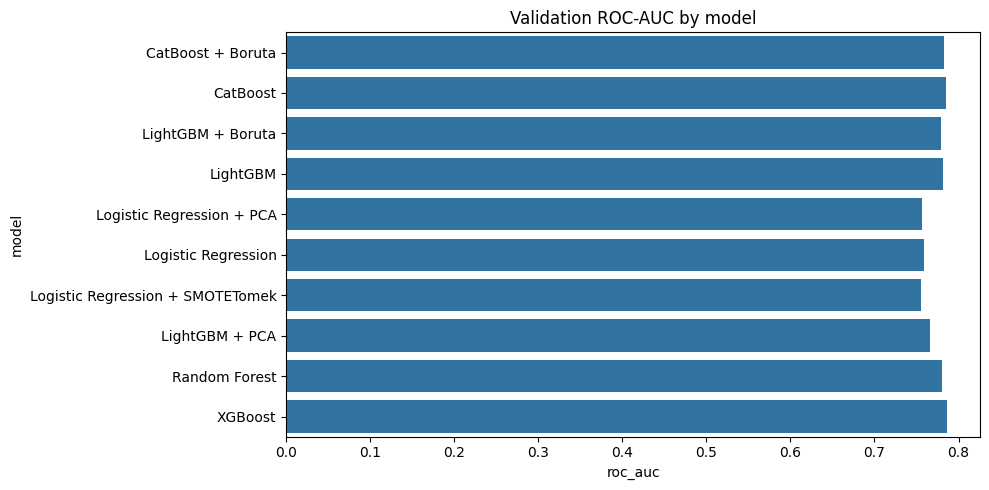

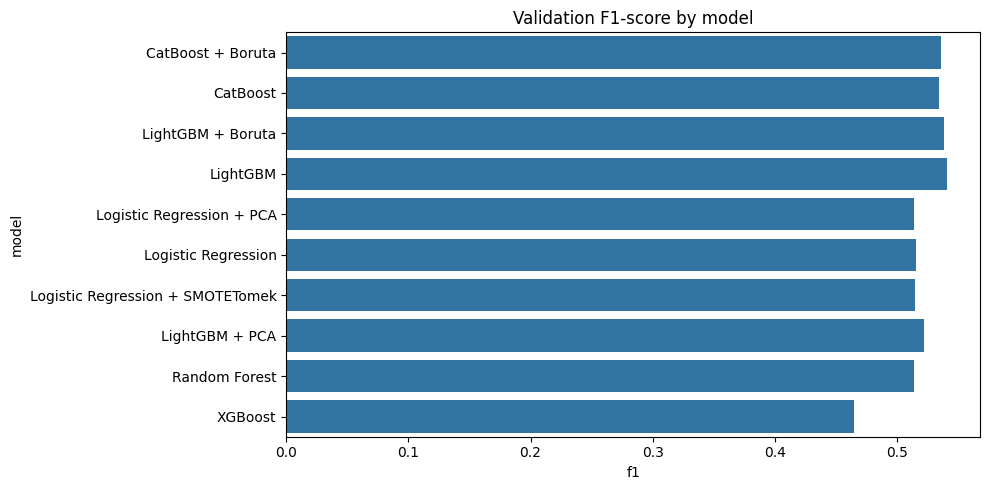

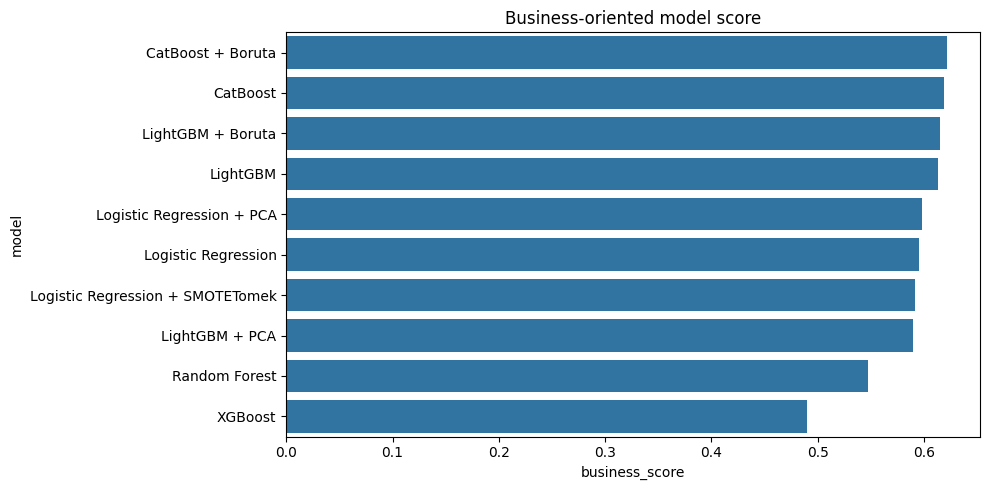

In [19]:
if len(results) == 0:
    raise ValueError("No model results found. Run model training cells first.")

results_df = pd.DataFrame(results).drop_duplicates(
    subset=["model", "dataset", "threshold"],
    keep="last"
)

# Business-oriented ranking: F1 and recall matter strongly in credit risk.
results_df["business_score"] = (
    0.45 * results_df["f1"] +
    0.35 * results_df["recall"] +
    0.20 * results_df["roc_auc"]
)

results_df = results_df.sort_values(
    ["business_score", "f1", "recall", "roc_auc"],
    ascending=False
)

display(results_df)

results_df.to_csv(PROJECT_DIR / "reports" / "model_validation_results.csv", index=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=results_df, x="roc_auc", y="model")
plt.title("Validation ROC-AUC by model")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "model_comparison_roc_auc.png", dpi=150)
plt.show()

plt.figure(figsize=(10, 5))
sns.barplot(data=results_df, x="f1", y="model")
plt.title("Validation F1-score by model")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "model_comparison_f1.png", dpi=150)
plt.show()

plt.figure(figsize=(10, 5))
sns.barplot(data=results_df, x="business_score", y="model")
plt.title("Business-oriented model score")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "model_comparison_business_score.png", dpi=150)
plt.show()

## 16. Choose final model and tune threshold

For credit risk, the default threshold `0.5` is not always optimal.  
A lower threshold often increases recall, meaning the model catches more risky clients.

,model,business_score,f1,recall,precision,roc_auc
9,CatBoost + Boruta,0.621617,0.535985,0.639789,0.461162,0.782489
4,CatBoost,0.618410,0.534268,0.631500,0.462983,0.784823
8,LightGBM + Boruta,0.614735,0.538361,0.618689,0.476494,0.779656
3,LightGBM,0.613635,0.541027,0.611153,0.485338,0.781346
6,Logistic Regression + PCA,0.598086,0.514340,0.614921,0.442037,0.757055
0,Logistic Regression,0.595474,0.515756,0.604371,0.449804,0.759272
7,LightGBM + PCA,0.589685,0.522393,0.575735,0.478098,0.765502
1,Random Forest,0.547790,0.514165,0.458176,0.585742,0.780272
2,XGBoost,0.490225,0.465047,0.353429,0.679710,0.786270


Final model selected: CatBoost + Boruta
Input type: boruta
Number of model features: 35


,threshold,precision,recall,f1,roc_auc,tp,fp,tn,fn,flagged_share,expected_cost
47,0.57,0.517149,0.579503,0.546553,0.782489,769,718,3955,558,0.247833,3508
48,0.58,0.526205,0.567445,0.546048,0.782489,753,678,3995,574,0.238500,3548
50,0.60,0.543820,0.547099,0.545455,0.782489,726,609,4064,601,0.222500,3614
49,0.59,0.533623,0.556142,0.544649,0.782489,738,645,4028,589,0.230500,3590
46,0.56,0.506165,0.587792,0.543933,0.782489,780,761,3912,547,0.256833,3496
45,0.55,0.497494,0.598342,0.543277,0.782489,794,802,3871,533,0.266000,3467
51,0.61,0.549961,0.535041,0.542399,0.782489,710,581,4092,617,0.215167,3666
52,0.62,0.558847,0.525998,0.541925,0.782489,698,551,4122,629,0.208167,3696
44,0.54,0.488429,0.604371,0.540249,0.782489,802,840,3833,525,0.273667,3465
53,0.63,0.564039,0.517709,0.539882,0.782489,687,531,4142,640,0.203000,3731


,threshold,precision,recall,f1,roc_auc,tp,fp,tn,fn,flagged_share,expected_cost
27,0.37,0.354050,0.807084,0.492188,0.782489,1071,1954,2719,256,0.504167,3234
29,0.39,0.373042,0.771665,0.502947,0.782489,1024,1721,2952,303,0.457500,3236
30,0.40,0.383321,0.755087,0.508500,0.782489,1002,1612,3061,325,0.435667,3237
26,0.36,0.345558,0.823662,0.486860,0.782489,1093,2070,2603,234,0.527167,3240
28,0.38,0.362123,0.786737,0.495962,0.782489,1044,1839,2834,283,0.480500,3254
32,0.42,0.404924,0.718915,0.518056,0.782489,954,1402,3271,373,0.392667,3267
31,0.41,0.392670,0.734740,0.511811,0.782489,975,1508,3165,352,0.413833,3268
25,0.35,0.336685,0.832705,0.479497,0.782489,1105,2177,2496,222,0.547000,3287
33,0.43,0.411739,0.703090,0.519343,0.782489,933,1333,3340,394,0.377667,3303
24,0.34,0.327506,0.847023,0.472368,0.782489,1124,2308,2365,203,0.572000,3323


Best F1 threshold: 0.5699999999999997
Minimum cost threshold: 0.3699999999999999
Final threshold strategy: max_f1
Final selected threshold: 0.5699999999999997


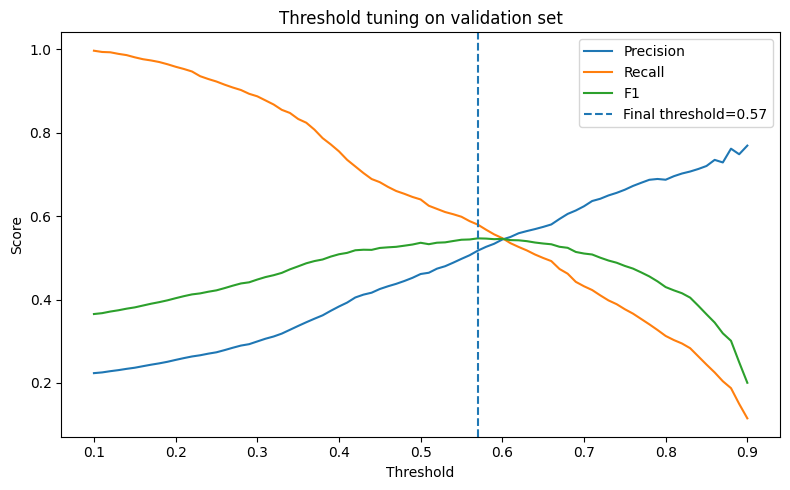

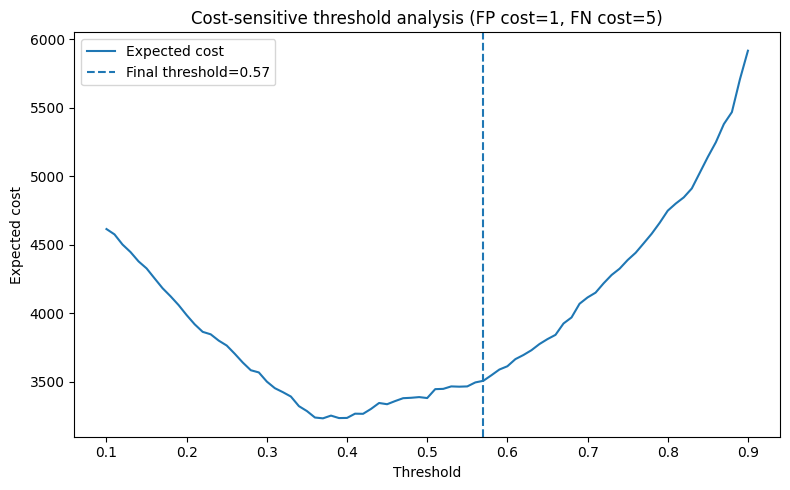

In [20]:
# Business-oriented final model selection and threshold tuning.
# The registry keeps track of how each model should receive input data.

def prepare_model_input(X_source, input_type, features=None):
    if features is None:
        features = X_source.columns.tolist()

    if input_type in ["raw", "boruta"]:
        return X_source[features]
    elif input_type == "scaled":
        return scaler.transform(X_source[features])
    elif input_type == "pca":
        return pca.transform(scaler.transform(X_source[features]))
    else:
        raise ValueError(f"Unknown input_type: {input_type}")

model_registry = {}

# Base models.
for name, spec in models.items():
    model_registry[name] = {
        "model": spec["model"],
        "input_type": spec["input"],
        "features": X.columns.tolist()
    }

# Optional models created in earlier sections.
if "tuned_lgbm" in globals():
    model_registry["LightGBM Tuned"] = {
        "model": tuned_lgbm,
        "input_type": "raw",
        "features": X.columns.tolist()
    }

if "lgbm_pca" in globals():
    model_registry["LightGBM + PCA"] = {
        "model": lgbm_pca,
        "input_type": "pca",
        "features": X.columns.tolist()
    }

if "logreg_pca" in globals():
    model_registry["Logistic Regression + PCA"] = {
        "model": logreg_pca,
        "input_type": "pca",
        "features": X.columns.tolist()
    }

if "selected_features_boruta" in globals() and selected_features_boruta:
    if "lgbm_boruta" in globals():
        model_registry["LightGBM + Boruta"] = {
            "model": lgbm_boruta,
            "input_type": "boruta",
            "features": selected_features_boruta
        }

    if "cat_boruta" in globals():
        model_registry["CatBoost + Boruta"] = {
            "model": cat_boruta,
            "input_type": "boruta",
            "features": selected_features_boruta
        }

candidate_results = results_df[results_df["model"].isin(model_registry.keys())].copy()

if candidate_results.empty:
    raise ValueError("No deployable candidate model found in results_df. Check model_registry and model names.")

candidate_results = candidate_results.sort_values(
    ["business_score", "f1", "recall", "roc_auc"],
    ascending=False
)

display(candidate_results[["model", "business_score", "f1", "recall", "precision", "roc_auc"]])

final_model_name = candidate_results.iloc[0]["model"]
final_registry = model_registry[final_model_name]
final_model = final_registry["model"]
final_input_type = final_registry["input_type"]
final_features = final_registry["features"]

print("Final model selected:", final_model_name)
print("Input type:", final_input_type)
print("Number of model features:", len(final_features))

X_val_final = prepare_model_input(X_val, final_input_type, final_features)
X_test_final = prepare_model_input(X_test, final_input_type, final_features)

_, _, val_proba = evaluate_model(final_model_name, final_model, X_val_final, y_val)

def threshold_metrics_table(y_true, y_proba, thresholds, fp_cost=1, fn_cost=5):
    rows = []

    for threshold in thresholds:
        y_pred_thr = (y_proba >= threshold).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred_thr).ravel()

        rows.append({
            "threshold": float(threshold),
            "precision": precision_score(y_true, y_pred_thr, zero_division=0),
            "recall": recall_score(y_true, y_pred_thr, zero_division=0),
            "f1": f1_score(y_true, y_pred_thr, zero_division=0),
            "roc_auc": roc_auc_score(y_true, y_proba),
            "tp": int(tp),
            "fp": int(fp),
            "tn": int(tn),
            "fn": int(fn),
            "flagged_share": float(y_pred_thr.mean()),
            "expected_cost": int(fp) * fp_cost + int(fn) * fn_cost
        })

    return pd.DataFrame(rows)

FP_COST = 1
FN_COST = 5
MIN_RECALL_FOR_BUSINESS = 0.55

threshold_df = threshold_metrics_table(
    y_val,
    val_proba,
    thresholds=np.arange(0.10, 0.91, 0.01),
    fp_cost=FP_COST,
    fn_cost=FN_COST
)

display(threshold_df.sort_values("f1", ascending=False).head(10))
display(threshold_df.sort_values("expected_cost", ascending=True).head(10))

best_f1_threshold = float(threshold_df.sort_values("f1", ascending=False).iloc[0]["threshold"])

business_candidates = threshold_df[threshold_df["recall"] >= MIN_RECALL_FOR_BUSINESS].copy()
if len(business_candidates) > 0:
    min_cost_threshold = float(business_candidates.sort_values("expected_cost", ascending=True).iloc[0]["threshold"])
else:
    min_cost_threshold = float(threshold_df.sort_values("expected_cost", ascending=True).iloc[0]["threshold"])

# You can switch between "max_f1" and "min_cost".
FINAL_THRESHOLD_STRATEGY = "max_f1"

if FINAL_THRESHOLD_STRATEGY == "min_cost":
    final_threshold = min_cost_threshold
else:
    final_threshold = best_f1_threshold

print("Best F1 threshold:", best_f1_threshold)
print("Minimum cost threshold:", min_cost_threshold)
print("Final threshold strategy:", FINAL_THRESHOLD_STRATEGY)
print("Final selected threshold:", final_threshold)

threshold_df.to_csv(PROJECT_DIR / "reports" / "threshold_tuning_validation.csv", index=False)

plt.figure(figsize=(8, 5))
plt.plot(threshold_df["threshold"], threshold_df["precision"], label="Precision")
plt.plot(threshold_df["threshold"], threshold_df["recall"], label="Recall")
plt.plot(threshold_df["threshold"], threshold_df["f1"], label="F1")
plt.axvline(final_threshold, linestyle="--", label=f"Final threshold={final_threshold:.2f}")
plt.title("Threshold tuning on validation set")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "threshold_tuning.png", dpi=150)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(threshold_df["threshold"], threshold_df["expected_cost"], label="Expected cost")
plt.axvline(final_threshold, linestyle="--", label=f"Final threshold={final_threshold:.2f}")
plt.title(f"Cost-sensitive threshold analysis (FP cost={FP_COST}, FN cost={FN_COST})")
plt.xlabel("Threshold")
plt.ylabel("Expected cost")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "threshold_cost_analysis.png", dpi=150)
plt.show()

## 17. Final test evaluation

model        CatBoost + Boruta
dataset                   test
threshold                 0.57
accuracy                 0.785
precision             0.512559
recall                0.568953
f1                    0.539286
roc_auc               0.780142
dtype: object

Classification report:
              precision    recall  f1-score   support

           0       0.87      0.85      0.86      4673
           1       0.51      0.57      0.54      1327

    accuracy                           0.79      6000
   macro avg       0.69      0.71      0.70      6000
weighted avg       0.79      0.79      0.79      6000



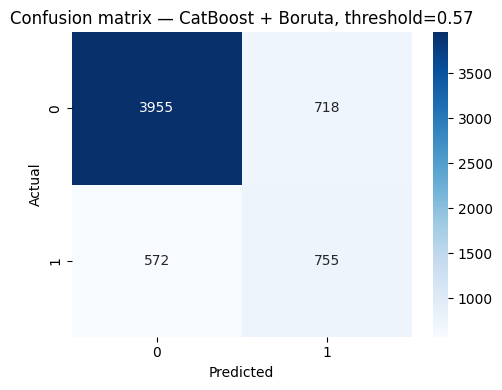

<Figure size 640x480 with 0 Axes>

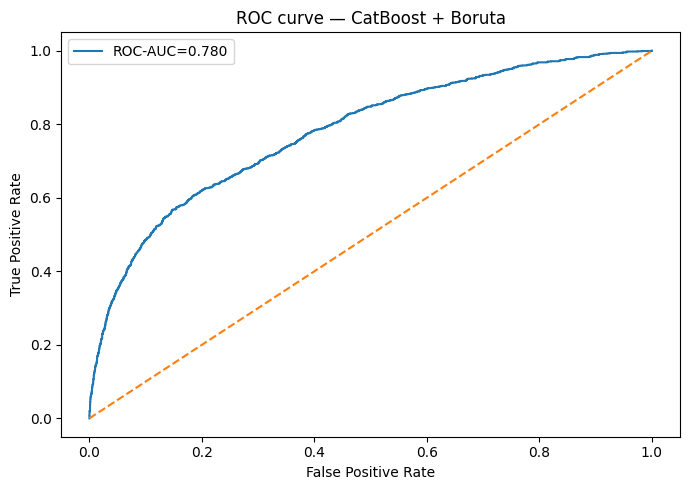

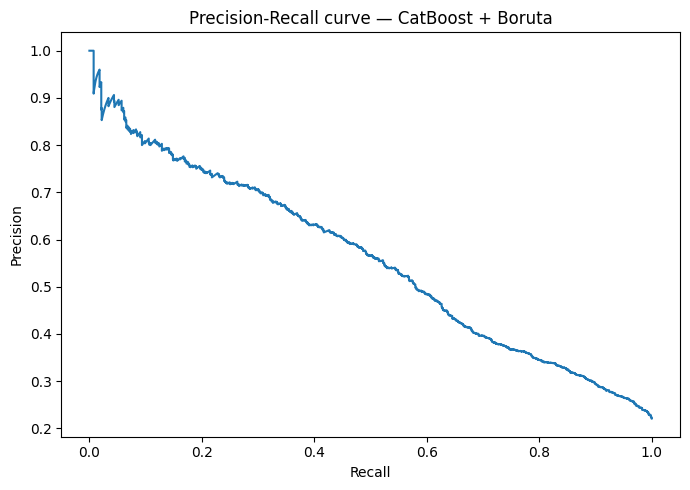

In [21]:
test_metrics, y_test_pred, y_test_proba = evaluate_model(
    final_model_name,
    final_model,
    X_test_final,
    y_test,
    dataset="test",
    threshold=float(final_threshold)
)

print(pd.Series(test_metrics))
print("\nClassification report:")
print(classification_report(y_test, y_test_pred, zero_division=0))

plot_confusion_matrix(
    y_test,
    y_test_pred,
    f"Confusion matrix — {final_model_name}, threshold={final_threshold:.2f}"
)

plt.savefig(FIGURES_DIR / "confusion_matrix_final_model.png", dpi=150, bbox_inches="tight")
plt.show()

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_test_proba)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"ROC-AUC={test_metrics['roc_auc']:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title(f"ROC curve — {final_model_name}")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "roc_curve_final_model.png", dpi=150)
plt.show()

# Precision-recall curve
precision_curve, recall_curve, pr_thresholds = precision_recall_curve(y_test, y_test_proba)

plt.figure(figsize=(7, 5))
plt.plot(recall_curve, precision_curve)
plt.title(f"Precision-Recall curve — {final_model_name}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "precision_recall_curve_final_model.png", dpi=150)
plt.show()

## 17A. Calibration and risk segmentation

The model outputs probabilities, but probability values are useful only if they are reasonably calibrated.  
A calibration plot compares predicted default probability with observed default frequency.

The notebook also creates risk bands and deciles. This is useful for business reporting because stakeholders often prefer segments such as low, medium and high risk instead of raw probabilities.

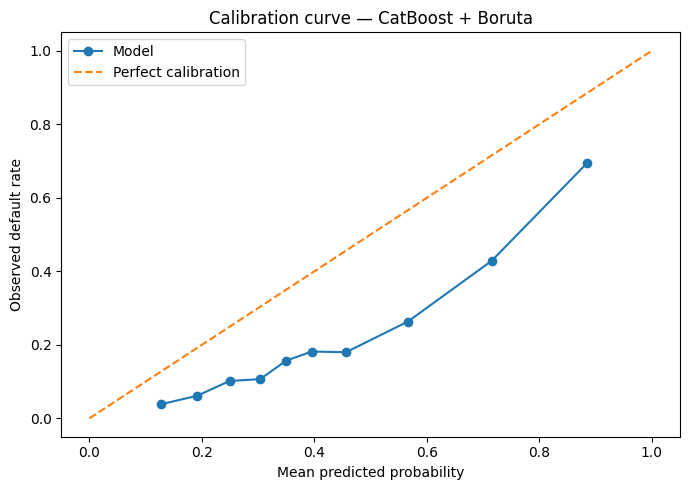

,risk_band,customers,observed_default_rate,avg_predicted_probability,predicted_default_share
0,Very low,981,0.042813,0.148413,0.000000
1,Low,1724,0.106148,0.279201,0.000000
2,Medium,1450,0.184828,0.410034,0.000000
3,High,927,0.288026,0.595733,0.598706
4,Very high,918,0.617647,0.838496,1.000000


,risk_decile,customers,observed_default_rate,avg_predicted_probability
0,1,600,0.693333,0.884158
1,2,600,0.428333,0.715110
2,3,600,0.263333,0.566234
3,4,600,0.180000,0.456548
4,5,600,0.181667,0.395027
5,6,600,0.156667,0.349518
6,7,600,0.106667,0.303684
7,8,600,0.101667,0.249347
8,9,600,0.061667,0.192027
9,10,600,0.038333,0.127463


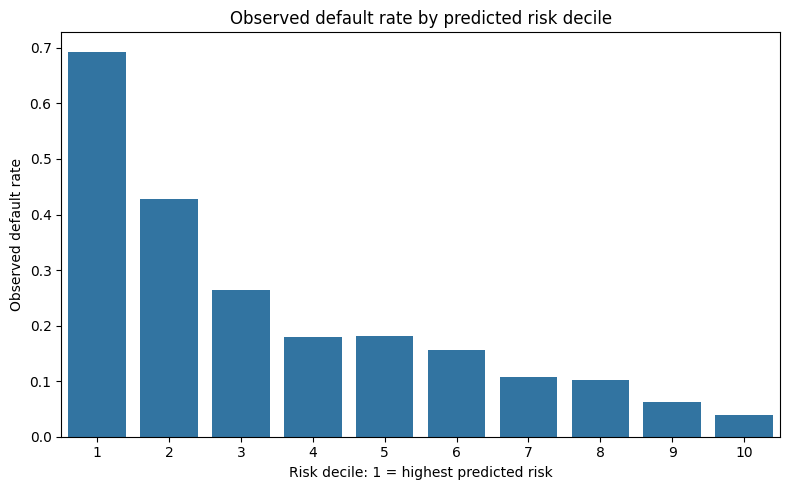

In [22]:
from sklearn.calibration import calibration_curve

# Calibration check
prob_true, prob_pred = calibration_curve(y_test, y_test_proba, n_bins=10, strategy="quantile")

plt.figure(figsize=(7, 5))
plt.plot(prob_pred, prob_true, marker="o", label="Model")
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")
plt.title(f"Calibration curve — {final_model_name}")
plt.xlabel("Mean predicted probability")
plt.ylabel("Observed default rate")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "calibration_curve_final_model.png", dpi=150)
plt.show()

# Risk segmentation
risk_df = X_test.copy()
risk_df["actual_default"] = y_test.values
risk_df["predicted_probability_default"] = y_test_proba
risk_df["predicted_default"] = y_test_pred

risk_bins = [-0.001, 0.20, 0.35, 0.50, 0.70, 1.001]
risk_labels = ["Very low", "Low", "Medium", "High", "Very high"]

risk_df["risk_band"] = pd.cut(
    risk_df["predicted_probability_default"],
    bins=risk_bins,
    labels=risk_labels
)

risk_summary = (
    risk_df
    .groupby("risk_band", observed=False)
    .agg(
        customers=("actual_default", "size"),
        observed_default_rate=("actual_default", "mean"),
        avg_predicted_probability=("predicted_probability_default", "mean"),
        predicted_default_share=("predicted_default", "mean")
    )
    .reset_index()
)

display(risk_summary)

risk_summary.to_csv(PROJECT_DIR / "reports" / "risk_band_summary_test.csv", index=False)

# Decile lift table: highest-risk decile should have the highest observed default rate.
risk_df["risk_decile"] = pd.qcut(
    risk_df["predicted_probability_default"],
    q=10,
    labels=False,
    duplicates="drop"
)

max_decile = risk_df["risk_decile"].max()
risk_df["risk_decile"] = max_decile - risk_df["risk_decile"] + 1

decile_summary = (
    risk_df
    .groupby("risk_decile")
    .agg(
        customers=("actual_default", "size"),
        observed_default_rate=("actual_default", "mean"),
        avg_predicted_probability=("predicted_probability_default", "mean")
    )
    .reset_index()
    .sort_values("risk_decile")
)

display(decile_summary)

decile_summary.to_csv(PROJECT_DIR / "reports" / "risk_decile_summary_test.csv", index=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=decile_summary, x="risk_decile", y="observed_default_rate")
plt.title("Observed default rate by predicted risk decile")
plt.xlabel("Risk decile: 1 = highest predicted risk")
plt.ylabel("Observed default rate")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "risk_decile_default_rate.png", dpi=150)
plt.show()

## 18. SHAP explainability

SHAP helps explain which variables increase or decrease predicted default risk.

 97%|=================== | 974/1000 [00:21<00:00]       

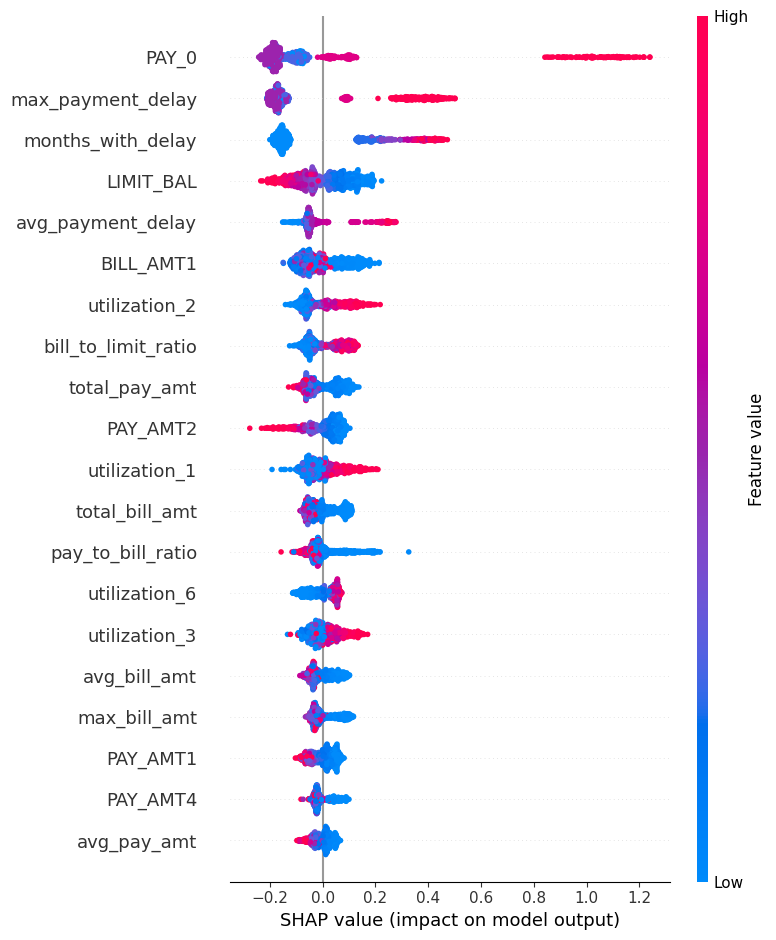

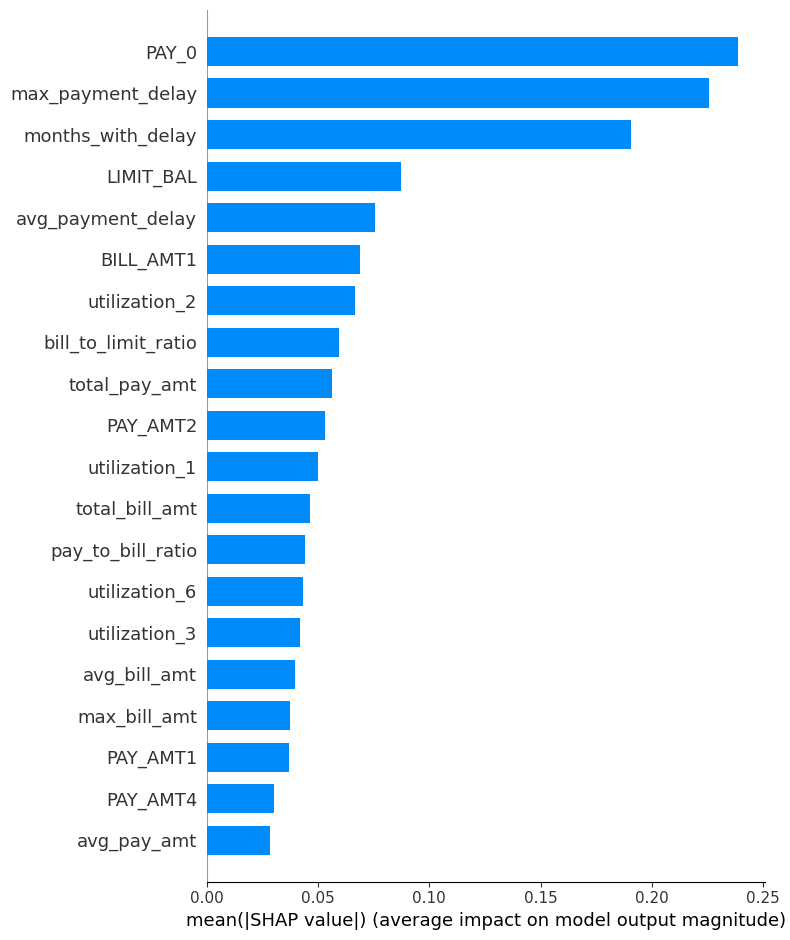

In [23]:
if HAS_SHAP:
    sample_size = min(1000, len(X_test))

    # SHAP is most interpretable on original feature columns.
    # For PCA models, SHAP explains components rather than business features, so we skip it.
    if final_input_type == "pca":
        print("SHAP skipped for PCA-based final model because components are less business-interpretable.")
        print("For explainability, consider selecting a raw-feature model such as LightGBM, XGBoost or CatBoost.")

    else:
        X_shap = X_test[final_features].sample(sample_size, random_state=SEED)
        X_background = X_train[final_features].sample(min(1000, len(X_train)), random_state=SEED)

        try:
            explainer = shap.Explainer(final_model, X_background)
            shap_values = explainer(X_shap)

            shap.summary_plot(shap_values, X_shap, show=False)
            plt.tight_layout()
            plt.savefig(FIGURES_DIR / "shap_summary.png", dpi=150, bbox_inches="tight")
            plt.show()

            shap.summary_plot(shap_values, X_shap, plot_type="bar", show=False)
            plt.tight_layout()
            plt.savefig(FIGURES_DIR / "shap_bar.png", dpi=150, bbox_inches="tight")
            plt.show()

        except Exception as e:
            print("Generic SHAP explainer failed:", e)
            print("Trying TreeExplainer...")

            try:
                explainer = shap.TreeExplainer(final_model)
                shap_values = explainer.shap_values(X_shap)

                if isinstance(shap_values, list):
                    shap_values_to_plot = shap_values[1]
                else:
                    shap_values_to_plot = shap_values

                shap.summary_plot(shap_values_to_plot, X_shap, show=False)
                plt.tight_layout()
                plt.savefig(FIGURES_DIR / "shap_summary.png", dpi=150, bbox_inches="tight")
                plt.show()

                shap.summary_plot(shap_values_to_plot, X_shap, plot_type="bar", show=False)
                plt.tight_layout()
                plt.savefig(FIGURES_DIR / "shap_bar.png", dpi=150, bbox_inches="tight")
                plt.show()

            except Exception as e2:
                print("SHAP failed for this model:", e2)
else:
    print("SHAP not installed. Skipping explainability.")

## 18A. Group-level sanity checks

Credit risk models should be reviewed carefully before any production use.  
This section is not a full fairness audit, but it provides a basic group-level check for selected demographic variables available in the dataset.

The goal is to compare:

- observed default rate,
- predicted positive rate,
- recall,
- precision,

across groups such as sex, education and marital status.

In [24]:
group_cols = [col for col in ["SEX", "EDUCATION", "MARRIAGE"] if col in X_test.columns]
group_rows = []

for col in group_cols:
    temp = pd.DataFrame({
        "group_value": X_test[col].values,
        "actual_default": y_test.values,
        "predicted_default": y_test_pred,
        "predicted_probability_default": y_test_proba
    })

    for group_value, group_data in temp.groupby("group_value"):
        if len(group_data) == 0:
            continue

        group_y_true = group_data["actual_default"].values
        group_y_pred = group_data["predicted_default"].values

        group_rows.append({
            "variable": col,
            "group_value": group_value,
            "customers": len(group_data),
            "observed_default_rate": group_data["actual_default"].mean(),
            "avg_predicted_probability": group_data["predicted_probability_default"].mean(),
            "predicted_positive_rate": group_data["predicted_default"].mean(),
            "precision": precision_score(group_y_true, group_y_pred, zero_division=0),
            "recall": recall_score(group_y_true, group_y_pred, zero_division=0),
            "f1": f1_score(group_y_true, group_y_pred, zero_division=0)
        })

group_metrics_df = pd.DataFrame(group_rows)

if len(group_metrics_df) > 0:
    display(group_metrics_df)
    group_metrics_df.to_csv(PROJECT_DIR / "reports" / "group_level_sanity_checks.csv", index=False)
else:
    print("No group-level columns available for sanity checks.")

,variable,group_value,customers,observed_default_rate,avg_predicted_probability,predicted_positive_rate,precision,recall,f1
0,SEX,1,2402,0.233555,0.430802,0.261032,0.503987,0.563280,0.531987
1,SEX,2,3598,0.212896,0.419312,0.235131,0.518913,0.573107,0.544665
2,EDUCATION,1,2130,0.190141,0.386004,0.192488,0.519512,0.525926,0.522699
3,EDUCATION,2,2774,0.236482,0.443593,0.279740,0.514175,0.608232,0.557263
4,EDUCATION,3,1014,0.257396,0.457453,0.278107,0.503546,0.544061,0.523020
5,EDUCATION,4,82,0.060976,0.328020,0.060976,0.200000,0.200000,0.200000
6,MARRIAGE,1,2767,0.241417,0.422922,0.247922,0.551020,0.565868,0.558346
7,MARRIAGE,2,3158,0.204877,0.424534,0.243825,0.484416,0.576507,0.526464
8,MARRIAGE,3,75,0.160000,0.434230,0.226667,0.235294,0.333333,0.275862


## 19. Save final artifacts

In [25]:
# Save model package, feature list, metrics and project metadata.

def to_jsonable(obj):
    if isinstance(obj, dict):
        return {str(k): to_jsonable(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [to_jsonable(v) for v in obj]
    if isinstance(obj, tuple):
        return tuple(to_jsonable(v) for v in obj)
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.floating,)):
        return float(obj)
    if isinstance(obj, (np.ndarray,)):
        return obj.tolist()
    return obj

model_package = {
    "model": final_model,
    "model_name": final_model_name,
    "threshold": float(final_threshold),
    "input_type": final_input_type,
    "features": final_features,
    "scaler": scaler if final_input_type in ["scaled", "pca"] else None,
    "pca": pca if final_input_type == "pca" else None
}

joblib.dump(model_package, MODELS_DIR / "best_model_package.pkl")
joblib.dump(final_model, MODELS_DIR / "best_classical_model.pkl")

with open(MODELS_DIR / "feature_columns.json", "w") as f:
    json.dump(final_features, f, indent=2)

with open(MODELS_DIR / "final_test_metrics.json", "w") as f:
    json.dump(to_jsonable(test_metrics), f, indent=2)

summary = {
    "final_model_name": final_model_name,
    "final_input_type": final_input_type,
    "final_threshold": float(final_threshold),
    "threshold_strategy": FINAL_THRESHOLD_STRATEGY,
    "fp_cost": FP_COST,
    "fn_cost": FN_COST,
    "test_metrics": to_jsonable(test_metrics),
    "n_train": int(len(X_train)),
    "n_validation": int(len(X_val)),
    "n_test": int(len(X_test)),
    "n_features_original": int(X.shape[1]),
    "n_features_final_model": int(len(final_features))
}

with open(MODELS_DIR / "project_summary.json", "w") as f:
    json.dump(to_jsonable(summary), f, indent=2)

# GitHub helper files
gitignore_text = '''
venv/
venv310/
__pycache__/
.ipynb_checkpoints/
data/raw/
models/
*.pkl
*.sav
*.h5
*.keras
.DS_Store
'''.strip()

(PROJECT_DIR / ".gitignore").write_text(gitignore_text, encoding="utf-8")

readme_generated = f'''
# Credit Card Default Prediction — Advanced ML Credit Risk Project

## Project overview

This project predicts whether a credit card client is likely to default next month.

The project is designed as a portfolio-ready credit risk machine learning case study. It includes EDA, feature engineering, model benchmarking, dimensionality reduction, feature selection, threshold tuning, explainability and risk segmentation.

## Business objective

The goal is to support credit risk assessment by estimating default probability. In this type of problem, accuracy alone is not enough because the target is imbalanced and false negatives may be more costly than false positives.

## Final model

- Final model: {final_model_name}
- Final threshold: {float(final_threshold):.2f}
- Threshold strategy: {FINAL_THRESHOLD_STRATEGY}

## Test metrics

- Accuracy: {test_metrics["accuracy"]:.3f}
- Precision: {test_metrics["precision"]:.3f}
- Recall: {test_metrics["recall"]:.3f}
- F1-score: {test_metrics["f1"]:.3f}
- ROC-AUC: {test_metrics["roc_auc"]:.3f}

## Techniques used

- Logistic Regression
- Random Forest
- XGBoost
- LightGBM
- CatBoost
- SMOTETomek
- VIF analysis
- PCA
- Boruta feature selection
- SHAP explainability
- Threshold tuning
- Cost-sensitive analysis
- Risk band segmentation
- Calibration curve
- Group-level sanity checks

## How to run

Place the dataset here:

```text
data/raw/UCI_Credit_Card.csv
```

Then run:

```bash
python -m venv venv
venv\\Scripts\\activate
pip install -r requirements.txt
jupyter lab
```

Open:

```text
notebooks/credit_card_default_advanced.ipynb
```

## Business interpretation

The model should be interpreted as a decision-support prototype, not as a production credit decision system. In a real banking environment, further validation, monitoring, calibration, regulatory review and fairness analysis would be required.
'''.strip()

(PROJECT_DIR / "README_GENERATED.md").write_text(readme_generated, encoding="utf-8")

summary

{'final_model_name': 'CatBoost + Boruta',
 'final_input_type': 'boruta',
 'final_threshold': 0.5699999999999997,
 'threshold_strategy': 'max_f1',
 'fp_cost': 1,
 'fn_cost': 5,
 'test_metrics': {'model': 'CatBoost + Boruta',
  'dataset': 'test',
  'threshold': 0.5699999999999997,
  'accuracy': 0.785,
  'precision': 0.5125594025797692,
  'recall': 0.5689525244913338,
  'f1': 0.5392857142857143,
  'roc_auc': 0.7801424947400215},
 'n_train': 18000,
 'n_validation': 6000,
 'n_test': 6000,
 'n_features_original': 41,
 'n_features_final_model': 35}

## 20. Business conclusions

This project should be presented as a **credit risk scoring prototype**.

Recommended final interpretation:

1. The target is imbalanced, so accuracy alone is not a reliable business metric.
2. Models were compared using ROC-AUC, F1-score, precision and recall.
3. Recall for the default class is especially important because missing risky clients may be costly.
4. Threshold tuning was used to adjust the trade-off between catching more risky clients and reducing false positives.
5. VIF showed strong multicollinearity caused by engineered financial features, which is expected.
6. PCA reduced dimensionality, but tree-based models usually performed better on original engineered features.
7. Boruta helped validate that repayment behavior and financial activity variables are more important than demographic variables.
8. SHAP was added to explain which features drive model predictions.
9. Risk segmentation converts probabilities into business-friendly groups.
10. Before production use, the model would require stronger validation, monitoring, fairness review and regulatory assessment.

### Suggested CV bullet

Built an end-to-end credit card default prediction project using Python and machine learning. Performed EDA, feature engineering, model benchmarking, class imbalance handling, VIF analysis, PCA, Boruta feature selection, threshold tuning, SHAP explainability, calibration analysis and risk segmentation. Compared Logistic Regression, Random Forest, XGBoost, LightGBM and CatBoost models using ROC-AUC, precision, recall and F1-score, with a focus on credit risk business interpretation.